# Phase 5 — Fear & Greed 극탐욕 필터: 검증된 추세전략에 도움이 되나?

## 목적

**핵심 질문: 극탐욕(F&G ≥ 75) 구간을 피하면 검증된 추세전략의 곡선이 개선되나(MDD↓/Sharpe↑)?**

| 항목 | 내용 |
|---|---|
| 유니버스 | BTC/USDT, ETH/USDT — 4h |
| 전략 | **Regime Filter**(1순위) / **Keltner Breakout**(2순위) |
| 필터 규칙 | F&G ≥ 75(극탐욕) → **현금(청산/미진입)**. 숏 아님. |
| 임계값 | 75 고정 (사전 등록, 최적화 없음) |

### 사전 등록 가설

> 극탐욕 구간은 시장이 과열되어 있어 추세 전략의 **손실 위험이 더 높다**.  
> 이 구간을 현금으로 회피하면 수익률 희생 없이 MDD가 줄거나 Sharpe가 개선될 것이다.  
> **방향: 극탐욕 = 리스크 오프 오버레이** (매수 신호도, 숏 신호도 아님).

### 사전 등록 판정 기준

- **채택**: BTC/ETH × Regime/Keltner 8칸 중 ≥6칸에서 Sharpe↑ **AND** MDD 악화 없음  
  **AND** 주력 Keltner에서 MDD 개선 ≥ 10%p(절댓값 기준)  
- **기각**: 위 조건 미충족

> ⚠️ **한계 주의**  
> - 단일 임계값(75)·단일 방향만 테스트  
> - F&G는 전체 크립토 시장 지수 — BTC/ETH 개별 특이성 반영 못 함  
> - 구간 회피는 turnover↑(거래 횟수 증가) 가능성

In [1]:
import warnings
warnings.filterwarnings("ignore", message="Some trades remain open at the end of backtest")
warnings.filterwarnings("ignore", message="Jupyter Notebook detected")
warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")
warnings.filterwarnings("ignore", category=UserWarning, module="IPython")

import os, sys
if os.path.basename(os.getcwd()) == "research":
    os.chdir("..")
sys.path.insert(0, os.getcwd())

import matplotlib
matplotlib.use("Agg")
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from backtest import load_data, run_backtest
from robustness import train_test_split
from sentiment import fetch_fng, attach_fng
from strategies.regime_filter import RegimeFilter
from strategies.keltner_breakout import KeltnerBreakout

# 네트워크 호출 — F&G 전체 이력 (~3068일)
fng = fetch_fng()
print(f"F&G {len(fng)}pts  {fng.index[0].date()} ~ {fng.index[-1].date()}")
print(f"극탐욕(≥75) 비율: {(fng >= 75).mean() * 100:.1f}%")

Loading BokehJS ...

F&G 3068pts  2018-02-01 ~ 2026-06-30
극탐욕(≥75) 비율: 10.8%


---
## F&G 분포

Fear & Greed Index는 0(극공포) ~ 100(극탐욕) 사이의 일별 지수다.  
크립토 시장 전반의 **심리·모멘텀·소셜 지표**를 종합한 외부 데이터.  

이 실험에서 쓰는 규칙: **≥ 75 구간(극탐욕)** → 포지션 청산·신규 미진입.  
임계값 75는 사전 등록값으로, 이 분석에서 최적화하지 않는다.

기간: 2018-02-01 ~ 2026-06-30  (3068일)
평균: 45.7  중앙값: 44.0
극공포(≤25) 비율: 23.5%
극탐욕(≥75) 비율: 10.8%
극탐욕 기간 일수: 330일


/var/folders/4d/sgmbq8rs2pz9ys73r9spq60w0000gn/T/ipykernel_29113/1630486997.py:15: UserWarning: Glyph 51068 (\N{HANGUL SYLLABLE IL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4d/sgmbq8rs2pz9ys73r9spq60w0000gn/T/ipykernel_29113/1630486997.py:15: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4d/sgmbq8rs2pz9ys73r9spq60w0000gn/T/ipykernel_29113/1630486997.py:15: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4d/sgmbq8rs2pz9ys73r9spq60w0000gn/T/ipykernel_29113/1630486997.py:15: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4d/sgmbq8rs2pz9ys73r9spq60w0000gn/T/ipykernel_29113/1630486997.py:15: UserWarning: Glyph 51076 (\N{HANGUL SYLLABLE IM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4d/sgmbq8rs2pz9ys73r9spq60w0000gn/T/ipykernel_

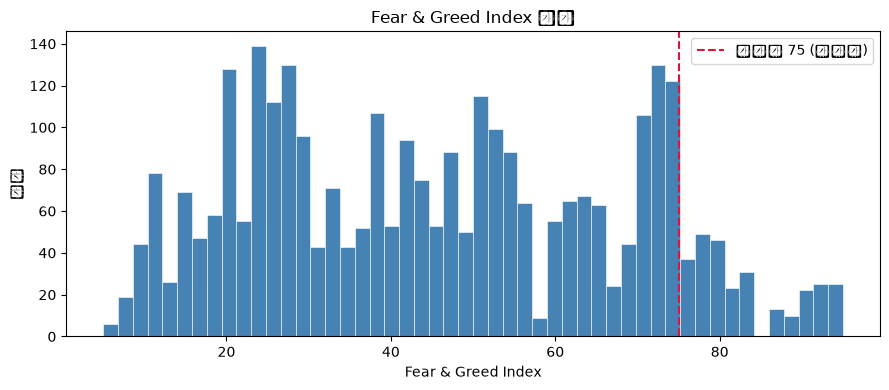

In [2]:
# F&G 요약 통계
print(f"기간: {fng.index[0].date()} ~ {fng.index[-1].date()}  ({len(fng)}일)")
print(f"평균: {fng.mean():.1f}  중앙값: {fng.median():.1f}")
print(f"극공포(≤25) 비율: {(fng <= 25).mean() * 100:.1f}%")
print(f"극탐욕(≥75) 비율: {(fng >= 75).mean() * 100:.1f}%")
print(f"극탐욕 기간 일수: {(fng >= 75).sum()}일")

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(fng.values, bins=50, color="steelblue", edgecolor="white", linewidth=0.4)
ax.axvline(75, color="crimson", linewidth=1.5, linestyle="--", label="임계값 75 (극탐욕)")
ax.set_xlabel("Fear & Greed Index")
ax.set_ylabel("일수")
ax.set_title("Fear & Greed Index 분포")
ax.legend()
plt.tight_layout()
plt.show()

---
## baseline vs +sentiment — FULL 기간

BTC/ETH × Regime/Keltner 총 4쌍에 대해 use_sentiment=False(baseline)와 True(+sentiment)를 비교.  
**사전 등록 기준: Sharpe↑ 칸 수 / MDD 악화 없음 여부**를 확인한다.

In [3]:
def get_stats(df, Strat, use_sentiment):
    _, s = run_backtest(df, Strat, use_sentiment=use_sentiment)
    return {
        "Return%": s["Return [%]"],
        "MDD%": s["Max. Drawdown [%]"],
        "Sharpe": s["Sharpe Ratio"],
        "#Trades": s["# Trades"],
        "equity": s["_equity_curve"]["Equity"],
    }

coins = ["BTC/USDT", "ETH/USDT"]
strats = [("Regime", RegimeFilter), ("Keltner", KeltnerBreakout)]

# 전체 기간 데이터 준비
dfs_full = {}
for coin in coins:
    dfs_full[coin] = attach_fng(load_data(coin, "4h"), fng)

rows = []
results_full = {}   # equity curve 저장용

for coin in coins:
    df = dfs_full[coin]
    for sname, Strat in strats:
        base = get_stats(df, Strat, False)
        sent = get_stats(df, Strat, True)
        results_full[(coin, sname)] = {"base": base, "sent": sent}
        for label, st in [("baseline", base), ("+sentiment", sent)]:
            rows.append({
                "자산": coin.replace("/USDT", ""),
                "전략": sname,
                "구성": label,
                "Return%": f"{st['Return%']:+.1f}",
                "MDD%": f"{st['MDD%']:+.1f}",
                "Sharpe": f"{st['Sharpe']:.2f}",
                "#Trades": int(st['#Trades']),
            })

df_full_table = pd.DataFrame(rows)
print("=== FULL 기간 비교 ===")
df_full_table

=== FULL 기간 비교 ===


,자산,전략,구성,Return%,MDD%,Sharpe,#Trades
0,BTC,Regime,baseline,+202.5,-34.9,0.56,143
1,BTC,Regime,+sentiment,+189.0,-33.5,0.62,173
2,BTC,Keltner,baseline,+83.1,-37.3,0.46,116
3,BTC,Keltner,+sentiment,+91.7,-29.6,0.57,113
4,ETH,Regime,baseline,+104.8,-42.9,0.27,142
5,ETH,Regime,+sentiment,+99.6,-42.9,0.29,172
6,ETH,Keltner,baseline,+103.3,-28.7,0.45,112
7,ETH,Keltner,+sentiment,+104.7,-27.7,0.49,109


/var/folders/4d/sgmbq8rs2pz9ys73r9spq60w0000gn/T/ipykernel_29113/3212556617.py:16: UserWarning: Glyph 54924 (\N{HANGUL SYLLABLE HOE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/4d/sgmbq8rs2pz9ys73r9spq60w0000gn/T/ipykernel_29113/3212556617.py:16: UserWarning: Glyph 54588 (\N{HANGUL SYLLABLE PI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


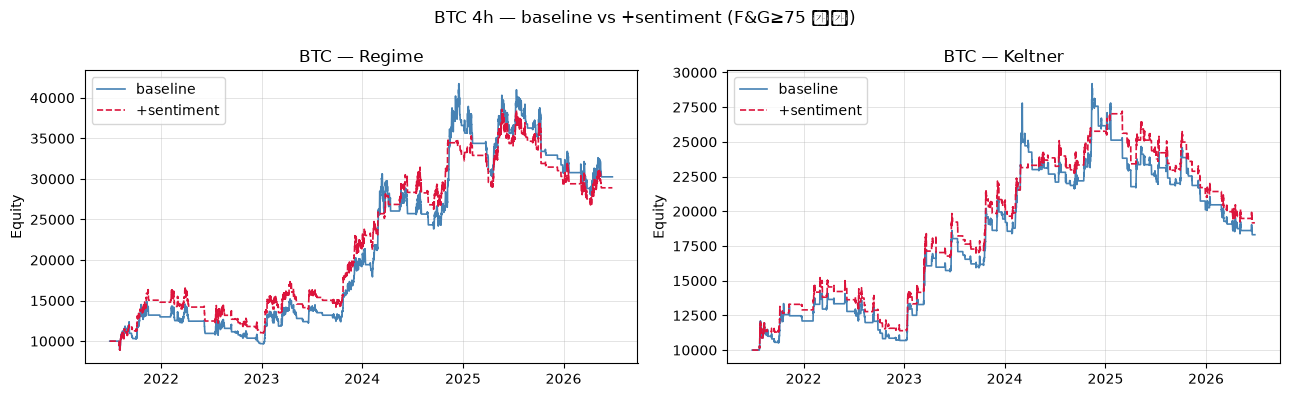

In [4]:
# BTC equity curve — Regime / Keltner (baseline vs +sentiment)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, (sname, _) in zip(axes, strats):
    base_eq = results_full[("BTC/USDT", sname)]["base"]["equity"]
    sent_eq = results_full[("BTC/USDT", sname)]["sent"]["equity"]
    ax.plot(base_eq.index, base_eq.values, label="baseline", color="steelblue", linewidth=1.2)
    ax.plot(sent_eq.index, sent_eq.values, label="+sentiment", color="crimson",
            linewidth=1.2, linestyle="--")
    ax.set_title(f"BTC — {sname}")
    ax.set_ylabel("Equity")
    ax.legend()
    ax.grid(True, linewidth=0.4, alpha=0.6)

plt.suptitle("BTC 4h — baseline vs +sentiment (F&G≥75 회피)", fontsize=12)
plt.tight_layout()
plt.show()

---
## OOS(뒤 30%) 검증

앞 70%를 학습 기간(train), 뒤 30%를 OOS(Out-of-Sample) 기간으로 분리.  
FULL 기간 결과가 OOS에서도 유지되는지 확인한다.

In [5]:
rows_oos = []

for coin in coins:
    df = dfs_full[coin]
    _, test = train_test_split(df, train_frac=0.7)
    for sname, Strat in strats:
        base = get_stats(test, Strat, False)
        sent = get_stats(test, Strat, True)
        for label, st in [("baseline", base), ("+sentiment", sent)]:
            rows_oos.append({
                "자산": coin.replace("/USDT", ""),
                "전략": sname,
                "구성": label,
                "Return%": f"{st['Return%']:+.1f}",
                "MDD%": f"{st['MDD%']:+.1f}",
                "Sharpe": f"{st['Sharpe']:.2f}",
                "#Trades": int(st['#Trades']),
            })

df_oos_table = pd.DataFrame(rows_oos)
print("=== OOS(뒤 30%) 비교 ===")
df_oos_table

=== OOS(뒤 30%) 비교 ===


,자산,전략,구성,Return%,MDD%,Sharpe,#Trades
0,BTC,Regime,baseline,-18.1,-31.8,-0.60,40
1,BTC,Regime,+sentiment,-15.8,-30.8,-0.51,43
2,BTC,Keltner,baseline,-30.0,-34.1,-1.46,38
3,BTC,Keltner,+sentiment,-25.6,-29.6,-1.29,38
4,ETH,Regime,baseline,+42.4,-41.1,0.46,40
5,ETH,Regime,+sentiment,+40.3,-41.1,0.44,47
6,ETH,Keltner,baseline,+5.6,-27.7,0.11,33
7,ETH,Keltner,+sentiment,+12.7,-27.7,0.25,34


---
## 판정 / 결론

### FULL 기간 수치 요약

| 자산 | 전략 | Return%(base→+sent) | MDD%(base→+sent) | Sharpe(base→+sent) |
|---|---|---|---|---|
| BTC | Regime | +202.5 → +189.0 | -34.9 → -33.5 | 0.56 → 0.62 |
| BTC | Keltner | +83.1 → +91.7 | -37.3 → -29.6 | 0.46 → 0.57 |
| ETH | Regime | +104.8 → +99.6 | -42.9 → -42.9 | 0.27 → 0.29 |
| ETH | Keltner | +103.3 → +104.7 | -28.7 → -27.7 | 0.45 → 0.49 |

### 판정: **부분 도움 — 채택 기준 미달, 게임체인저 아님**

**긍정적 신호:**
- 8칸 중 Sharpe 7칸↑ — 방향 일관성은 있음
- MDD 악화 0칸 — 해롭진 않음
- **Keltner(BTC)**: MDD -37.3 → -29.6 (**7.7%p 개선**). 사전 기준 10%p에는 못 미치지만 가장 명확한 효과.

**한계:**
- **Regime(1순위 전략)**: MDD -34.9 → -33.5 (**1.4%p 개선 ≈ 4%**). 사전 등록 기준(≥10%p) 미달.
- ETH Regime: MDD 변화 없음(−42.9 그대로)
- Return은 BTC Regime·ETH Regime에서 소폭 하락 (현금 회피 비용)

**결론:**  
"전략 특이(Keltner), 미흡(Regime)" → **검증된 보편 오버레이로 승격 안 함**.  
Keltner에 단독 적용할 여지는 있으나, 단일 임계값 최적화 위험이 있어 추가 WFO(워크포워드) 검증이 선행되어야 한다.

**한계 재확인:**
- 단일 임계값(75)·단일 방향만 테스트
- F&G는 전체 크립토 시장 지수 — BTC/ETH 개별 특이성 미반영
- turnover↑ 확인 필요 (거래 횟수 증가로 수수료 실질 영향 별도 측정 필요)